MDF_DATASET


Output Variables Statistics:
        Cutting_Force     Roughness    Wear_Rate    Vibration  Temperature  \
count    5000.000000   5000.000000  5000.000000  5000.000000  5000.000000   
mean      250.466819     88.585895     0.000013     0.003922   140.147656   
std       182.165417    539.819376     0.000005     0.000993    93.901926   
min         8.759486      0.000700     0.000002     0.001327     3.725870   
25%       112.949909      1.178208     0.000008     0.003205    68.453999   
50%       206.981643      4.666889     0.000012     0.003903   120.852097   
75%       344.710660     18.304974     0.000016     0.004622   191.809700   
max      1569.591545  14880.747862     0.000036     0.007447   597.500685   

       Chip_Load_Deviation  Power_Consumption  
count          5000.000000        5000.000000  
mean              2.987779         958.483798  
std               6.255112         886.826363  
min               0.000691          11.303608  
25%               0.467138         

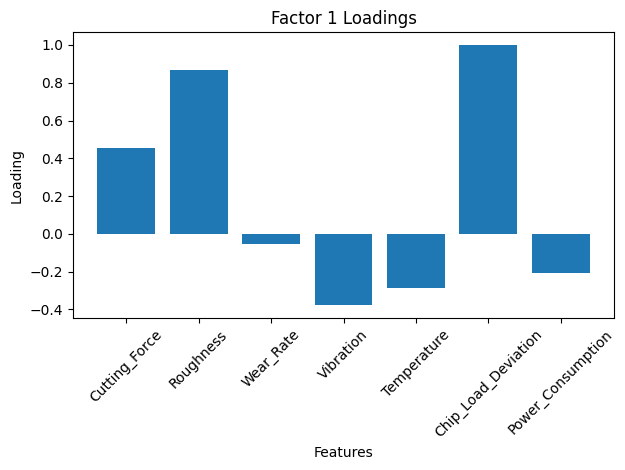

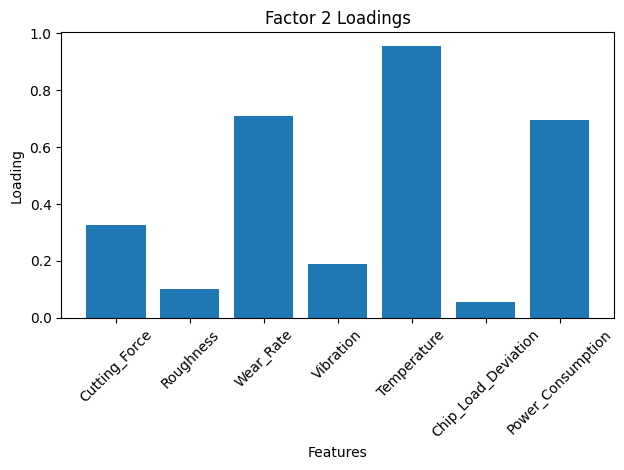

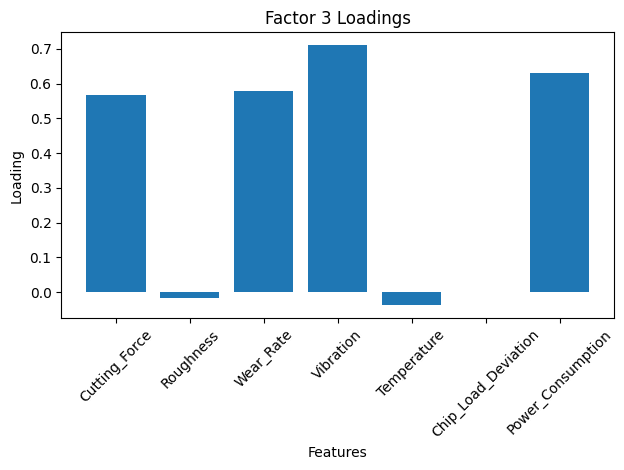

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import FactorAnalysis

def wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z):
    """ Cutting Force (N) for MDF without clamping. """
    v_c = (np.pi * D * N) / 1000.0  # Cutting speed (m/min)
    f_z = F / (N * z) if (N * z) else 0.0  # Feed per tooth (mm/tooth)

    C_f = 15.0
    alpha_vc = 0.2
    alpha_fz = 0.5
    alpha_ap = 1.0
    alpha_w  = 0.4
    alpha_rk = 0.03
    alpha_rf = 0.02
    alpha_hx = -0.005

    chi_ct = np.sqrt(1.0 - (w / D)**2) if w < D else 1.0

    return (C_f *
            ((v_c / 120.0)**alpha_vc) *
            ((f_z / 0.08)**alpha_fz) *
            (ap**alpha_ap) *
            (w**alpha_w) *
            np.exp(alpha_rk * (rake - 8.0)) *
            np.exp(alpha_rf * (relief - 8.0)) *
            np.exp(alpha_hx * (helix - 35.0)) *
            chi_ct)

def wood_surface_roughness(N, F, ap, w, rake, relief, helix, D, z, corner_radius=1.0):
    """ Surface Roughness (µm) for MDF without clamping. """
    v_c = (np.pi * D * N) / 1000.0  # m/min
    f_z = F / (N * z) if (N * z) else 0.0
    R_geo = (f_z**2) / (8 * corner_radius) if corner_radius > 0 else f_z**2

    k_dyn = 0.3
    phi_ap = 0.3
    phi_w  = 0.2
    phi_rk = -0.01
    Delta_dyn = k_dyn * (ap**phi_ap) * (w**phi_w) * np.exp(phi_rk * (rake - 8.0))

    speed_factor = (120.0 / v_c)**0.15
    return (R_geo * (1.0 + Delta_dyn) * speed_factor) * 1e3

def wood_tool_wear_rate(N, F, ap, w, rake, relief, helix, D, z):
    """ Tool Wear Rate (dimensionless) without clamping. """
    v_c = (np.pi * D * N) / 1000.0
    f_z = F / (N * z) if (N * z) else 0.0

    C_w = 2.5e-6
    x_vc = 0.6
    x_fz = 0.4
    x_ap = 0.3
    x_w  = 0.2
    x_rk = 0.02
    x_rf = 0.01
    x_hx = 0.005

    return (C_w *
            ((v_c / 120.0)**x_vc) *
            ((f_z / 0.08)**x_fz) *
            (ap**x_ap) *
            (w**x_w) *
            np.exp(x_rk * (rake - 8.0)) *
            np.exp(x_rf * (relief - 8.0)) *
            np.exp(x_hx * (helix - 35.0)))

def wood_vibration_amplitude(N, F, ap, w, rake, relief, helix, D, z):
    """ Vibration Amplitude (dimensionless) without clamping. """
    omega_t = 2 * np.pi * (z * N / 60.0)
    omega_0 = 400.0

    C_v = 0.0008
    d1 = 0.2
    d2 = 0.3
    d3 = 0.4
    d_rk = 0.015
    d_rf = -0.01
    d_hx = 0.005

    return (C_v *
            ((omega_t / omega_0)**d1) *
            (ap**d2) *
            (w**d3) *
            np.exp(d_rk * (rake - 8.0)) *
            np.exp(d_rf * (relief - 8.0)) *
            np.exp(d_hx * (helix - 35.0)))

def wood_cutting_temperature(N, F, ap, w, rake, relief, helix, D, z):
    """ Cutting Temperature (°C) without clamping. """
    Fc = wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z)
    v_c = (np.pi * D * N) / 1000.0
    v_c_s = v_c / 60.0
    effective_area = w * ap if (w * ap) > 0 else 1.0

    C_t = 5.0
    return C_t * (Fc * v_c_s) / effective_area

def wood_chip_load_deviation(N, F, ap, w, rake, relief, helix, D, z):
    """ Chip Load Deviation (dimensionless) without clamping. """
    f_z = F / (N * z) if (N * z) else 0.0  # Actual feed per tooth
    f_z_ideal = 0.08  # Ideal reference feed per tooth for MDF (adjust if needed)

    return abs(f_z - f_z_ideal) / f_z_ideal if f_z_ideal > 0 else 0.0

def wood_power_consumption(N, F, ap, w, rake, relief, helix, D, z):
    """ Power Consumption (W) without clamping. """
    Fc = wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z)
    v_c = (np.pi * D * N) / 1000.0
    v_c_s = v_c / 60.0
    return Fc * v_c_s

def generate_synthetic_data(num_samples=5000):
    """ Generate synthetic MDF cutting data without clamps or noise. """
    feeds = np.random.uniform(100, 8000, num_samples)
    depths = np.random.uniform(1, 10, num_samples)
    spindle_speeds = np.random.uniform(500, 17000, num_samples)
    tool_diameters = np.random.choice([6, 8, 10, 12], num_samples)
    wocs = np.array([np.random.uniform(0.5 * d, 0.9 * d) for d in tool_diameters])
    rakes = np.array([np.random.uniform(12, 16) if d < 10 else np.random.uniform(10, 14) for d in tool_diameters])
    reliefs = np.random.uniform(10, 14, num_samples)
    helixes = np.random.uniform(30, 40, num_samples)
    flutes = np.random.randint(2, 5, num_samples)

    outputs = []
    for N, F, ap, D, w, rake, relief, helix, z in zip(
            spindle_speeds, feeds, depths, tool_diameters, wocs, rakes, reliefs, helixes, flutes):
        outputs.append([
            wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z),
            wood_surface_roughness(N, F, ap, w, rake, relief, helix, D, z),
            wood_tool_wear_rate(N, F, ap, w, rake, relief, helix, D, z),
            wood_vibration_amplitude(N, F, ap, w, rake, relief, helix, D, z),
            wood_cutting_temperature(N, F, ap, w, rake, relief, helix, D, z),
            wood_chip_load_deviation(N, F, ap, w, rake, relief, helix, D, z),
            wood_power_consumption(N, F, ap, w, rake, relief, helix, D, z)
        ])

    return np.array(outputs)

if __name__ == "__main__":
    # Generate synthetic output data
    y = generate_synthetic_data(num_samples=5000)
    df_out = pd.DataFrame(y, columns=[
        "Cutting_Force", "Roughness", "Wear_Rate", "Vibration",
        "Temperature", "Chip_Load_Deviation", "Power_Consumption"
    ])
    print("\nOutput Variables Statistics:\n", df_out.describe())

    # Normalize the outputs using StandardScaler
    scaler = StandardScaler()
    y_normalized = scaler.fit_transform(df_out)
    df_normalized = pd.DataFrame(y_normalized, columns=df_out.columns)
    print("\nNormalized Output Variables Statistics:\n", df_normalized.describe())

    # ----- Factor Analysis -----
    # Set the number of latent factors to extract (adjust as needed)
    n_factors = 3
    fa = FactorAnalysis(n_components=n_factors, random_state=42)
    fa.fit(df_normalized)

    # Obtain factor loadings
    loadings = fa.components_.T  # shape: (n_features, n_factors)
    loadings_df = pd.DataFrame(loadings, index=df_normalized.columns,
                               columns=[f'Factor{i+1}' for i in range(n_factors)])
    print("\nFactor Loadings:\n", loadings_df)

    # Plot factor loadings for each factor
    for i in range(n_factors):
        plt.figure()
        plt.bar(df_normalized.columns, loadings[:, i])
        plt.title(f'Factor {i+1} Loadings')
        plt.xlabel('Features')
        plt.ylabel('Loading')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()


FEATURE ANALYSIS

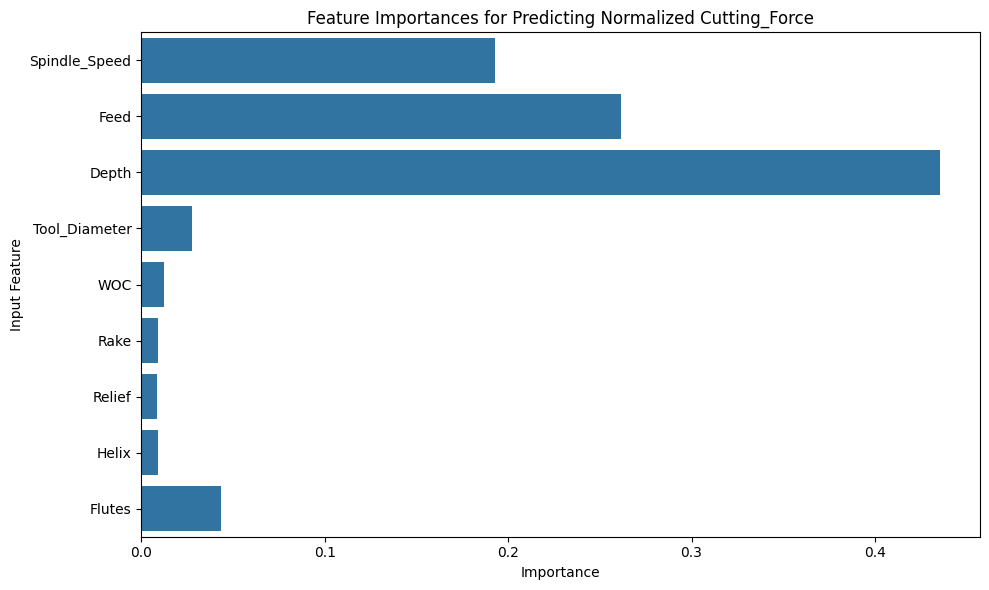

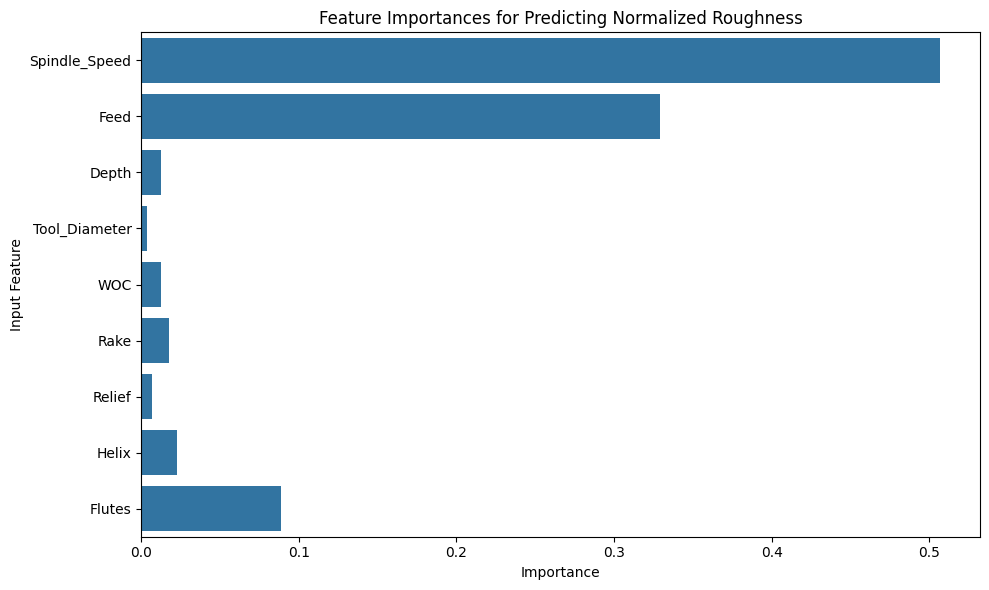

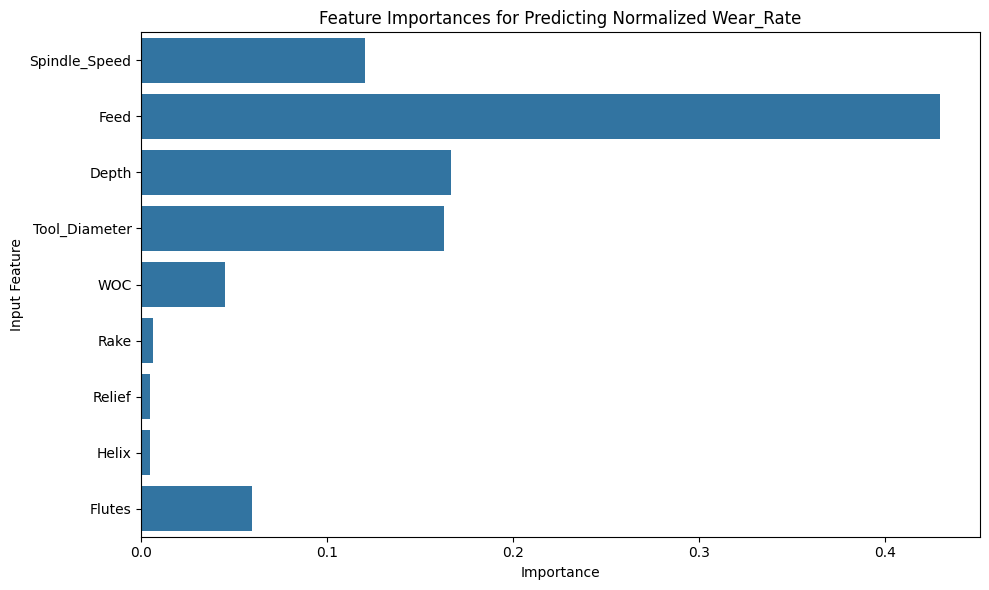

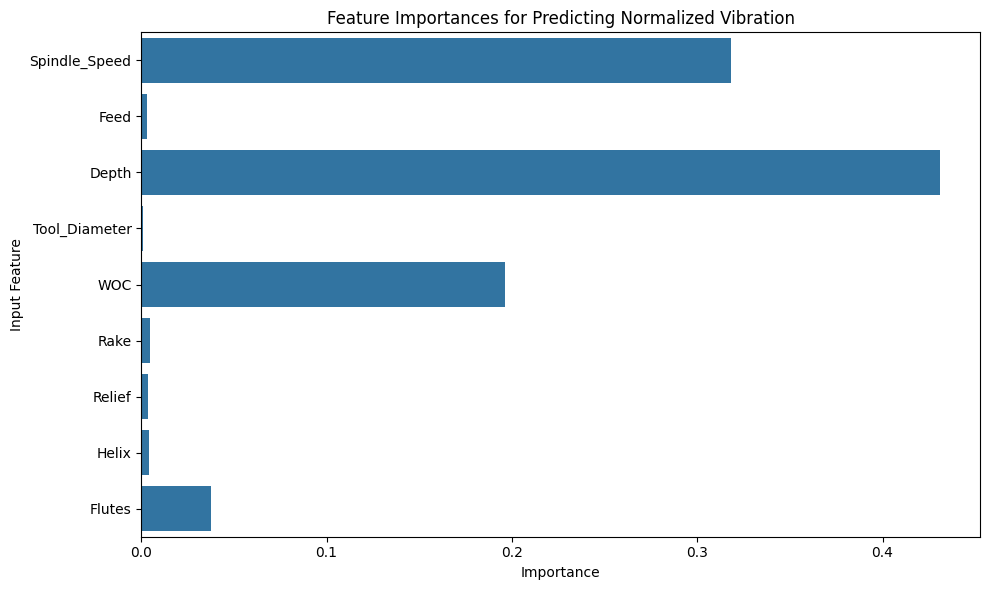

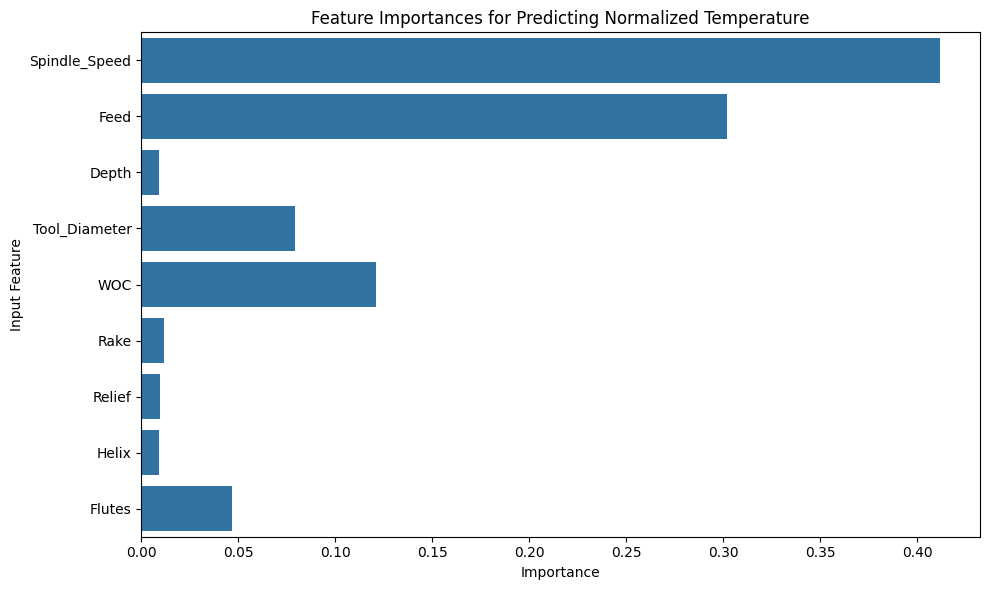

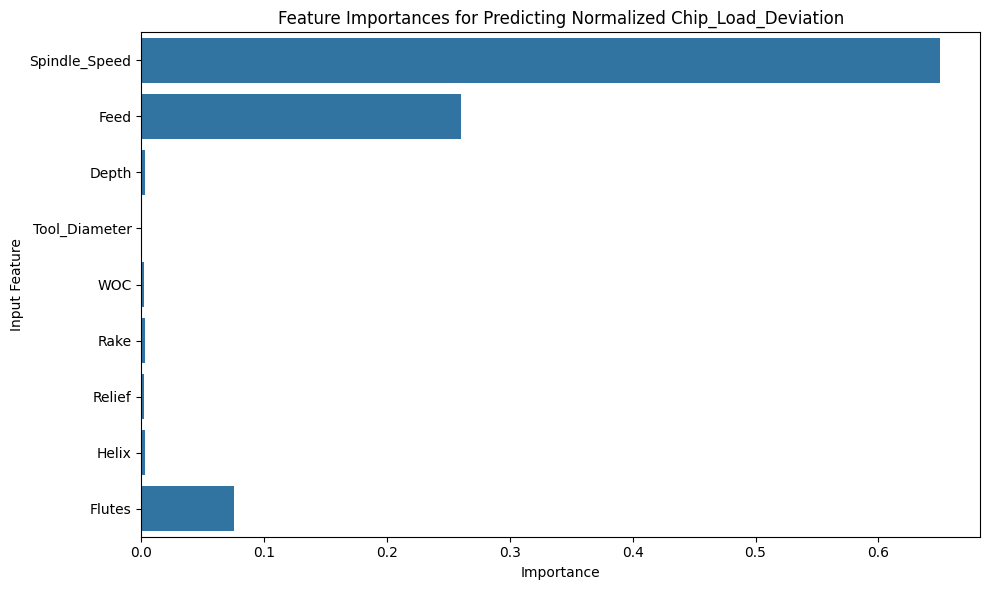

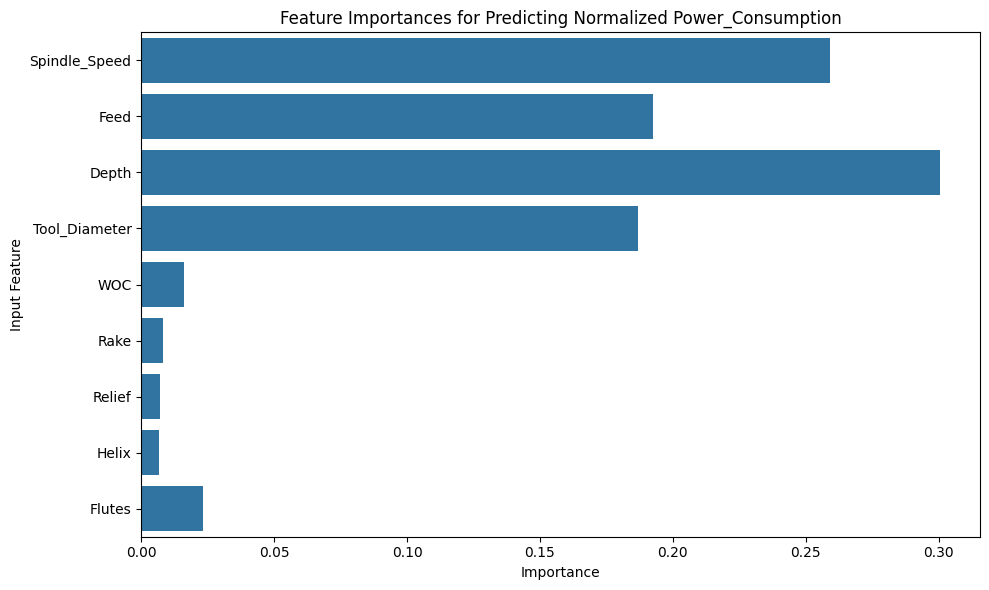

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# ---------------- Wood Cutting Functions ----------------
def wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z):
    """ Cutting Force (N) for MDF without clamping. """
    v_c = (np.pi * D * N) / 1000.0  # Cutting speed (m/min)
    f_z = F / (N * z) if (N * z) else 0.0  # Feed per tooth (mm/tooth)
    C_f = 15.0
    alpha_vc = 0.2
    alpha_fz = 0.5
    alpha_ap = 1.0
    alpha_w  = 0.4
    alpha_rk = 0.03
    alpha_rf = 0.02
    alpha_hx = -0.005
    chi_ct = np.sqrt(1.0 - (w / D)**2) if w < D else 1.0
    return (C_f *
            ((v_c / 120.0)**alpha_vc) *
            ((f_z / 0.08)**alpha_fz) *
            (ap**alpha_ap) *
            (w**alpha_w) *
            np.exp(alpha_rk * (rake - 8.0)) *
            np.exp(alpha_rf * (relief - 8.0)) *
            np.exp(alpha_hx * (helix - 35.0)) *
            chi_ct)

def wood_surface_roughness(N, F, ap, w, rake, relief, helix, D, z, corner_radius=1.0):
    """ Surface Roughness (µm) for MDF without clamping. """
    v_c = (np.pi * D * N) / 1000.0  # m/min
    f_z = F / (N * z) if (N * z) else 0.0
    R_geo = (f_z**2) / (8 * corner_radius) if corner_radius > 0 else f_z**2
    k_dyn = 0.3
    phi_ap = 0.3
    phi_w  = 0.2
    phi_rk = -0.01
    Delta_dyn = k_dyn * (ap**phi_ap) * (w**phi_w) * np.exp(phi_rk * (rake - 8.0))
    speed_factor = (120.0 / v_c)**0.15
    return (R_geo * (1.0 + Delta_dyn) * speed_factor) * 1e3

def wood_tool_wear_rate(N, F, ap, w, rake, relief, helix, D, z):
    """ Tool Wear Rate (dimensionless) without clamping. """
    v_c = (np.pi * D * N) / 1000.0
    f_z = F / (N * z) if (N * z) else 0.0
    C_w = 2.5e-6
    x_vc = 0.6
    x_fz = 0.4
    x_ap = 0.3
    x_w  = 0.2
    x_rk = 0.02
    x_rf = 0.01
    x_hx = 0.005
    return (C_w *
            ((v_c / 120.0)**x_vc) *
            ((f_z / 0.08)**x_fz) *
            (ap**x_ap) *
            (w**x_w) *
            np.exp(x_rk * (rake - 8.0)) *
            np.exp(x_rf * (relief - 8.0)) *
            np.exp(x_hx * (helix - 35.0)))

def wood_vibration_amplitude(N, F, ap, w, rake, relief, helix, D, z):
    """ Vibration Amplitude (dimensionless) without clamping. """
    omega_t = 2 * np.pi * (z * N / 60.0)
    omega_0 = 400.0
    C_v = 0.0008
    d1 = 0.2
    d2 = 0.3
    d3 = 0.4
    d_rk = 0.015
    d_rf = -0.01
    d_hx = 0.005
    return (C_v *
            ((omega_t / omega_0)**d1) *
            (ap**d2) *
            (w**d3) *
            np.exp(d_rk * (rake - 8.0)) *
            np.exp(d_rf * (relief - 8.0)) *
            np.exp(d_hx * (helix - 35.0)))

def wood_cutting_temperature(N, F, ap, w, rake, relief, helix, D, z):
    """ Cutting Temperature (°C) without clamping. """
    Fc = wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z)
    v_c = (np.pi * D * N) / 1000.0
    v_c_s = v_c / 60.0
    effective_area = w * ap if (w * ap) > 0 else 1.0
    C_t = 5.0
    return C_t * (Fc * v_c_s) / effective_area

def wood_chip_load_deviation(N, F, ap, w, rake, relief, helix, D, z):
    """ Chip Load Deviation (dimensionless) without clamping. """
    f_z = F / (N * z) if (N * z) else 0.0  # Actual feed per tooth
    f_z_ideal = 0.08  # Ideal reference feed per tooth for MDF (adjust if needed)
    return abs(f_z - f_z_ideal) / f_z_ideal if f_z_ideal > 0 else 0.0

def wood_power_consumption(N, F, ap, w, rake, relief, helix, D, z):
    """ Power Consumption (W) without clamping. """
    Fc = wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z)
    v_c = (np.pi * D * N) / 1000.0
    v_c_s = v_c / 60.0
    return Fc * v_c_s

# ---------------- Synthetic Dataset Generation ----------------
def generate_synthetic_dataset(num_samples=5000):
    """
    Generate a synthetic MDF cutting dataset.
    Returns:
      df_features: DataFrame with input features.
      df_outputs:  DataFrame with computed output variables.
    """
    # Generate input features
    feeds = np.random.uniform(100, 8000, num_samples)
    depths = np.random.uniform(1, 10, num_samples)
    spindle_speeds = np.random.uniform(500, 17000, num_samples)
    tool_diameters = np.random.choice([6, 8, 10, 12], num_samples)
    wocs = np.array([np.random.uniform(0.5 * d, 0.9 * d) for d in tool_diameters])
    rakes = np.array([np.random.uniform(12, 16) if d < 10 else np.random.uniform(10, 14)
                       for d in tool_diameters])
    reliefs = np.random.uniform(10, 14, num_samples)
    helixes = np.random.uniform(30, 40, num_samples)
    flutes = np.random.randint(2, 5, num_samples)

    # Create DataFrame for input features
    df_features = pd.DataFrame({
        'Spindle_Speed': spindle_speeds,
        'Feed': feeds,
        'Depth': depths,
        'Tool_Diameter': tool_diameters,
        'WOC': wocs,
        'Rake': rakes,
        'Relief': reliefs,
        'Helix': helixes,
        'Flutes': flutes
    })

    # Calculate output variables using the wood cutting functions
    outputs = []
    for N, F, ap, D, w, rake, relief, helix, z in zip(
            spindle_speeds, feeds, depths, tool_diameters, wocs, rakes, reliefs, helixes, flutes):
        outputs.append([
            wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z),
            wood_surface_roughness(N, F, ap, w, rake, relief, helix, D, z),
            wood_tool_wear_rate(N, F, ap, w, rake, relief, helix, D, z),
            wood_vibration_amplitude(N, F, ap, w, rake, relief, helix, D, z),
            wood_cutting_temperature(N, F, ap, w, rake, relief, helix, D, z),
            wood_chip_load_deviation(N, F, ap, w, rake, relief, helix, D, z),
            wood_power_consumption(N, F, ap, w, rake, relief, helix, D, z)
        ])
    df_outputs = pd.DataFrame(outputs, columns=[
        "Cutting_Force", "Roughness", "Wear_Rate", "Vibration",
        "Temperature", "Chip_Load_Deviation", "Power_Consumption"
    ])

    return df_features, df_outputs

# ---------------- Main Analysis ----------------
# Define df_features and df_outputs using our dataset generation function
df_features, df_outputs = generate_synthetic_dataset(num_samples=5000)

# Normalize the inputs and outputs separately using StandardScaler
scaler_X = StandardScaler()
X_normalized = pd.DataFrame(scaler_X.fit_transform(df_features), columns=df_features.columns)

scaler_y = StandardScaler()
y_normalized = pd.DataFrame(scaler_y.fit_transform(df_outputs), columns=df_outputs.columns)

# ----- Feature Importance Analysis -----
# For each output variable, use only the normalized input features as predictors.
for target in y_normalized.columns:
    X = X_normalized.copy()  # Only input features
    y = y_normalized[target]  # Target output

    # Train a RandomForestRegressor
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X, y)
    importances = rf_model.feature_importances_

    # Plot the feature importances
    plt.figure(figsize=(10, 6))
    sns.barplot(x=importances, y=X.columns)
    plt.title(f"Feature Importances for Predicting Normalized {target}")
    plt.xlabel("Importance")
    plt.ylabel("Input Feature")
    plt.tight_layout()
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming X_normalized (inputs) and y_normalized (outputs) are already defined.
# For example, from the previous snippet:
#   df_features, df_outputs = generate_synthetic_dataset(num_samples=5000)
#   X_normalized = pd.DataFrame(scaler_X.fit_transform(df_features), columns=df_features.columns)
#   y_normalized = pd.DataFrame(scaler_y.fit_transform(df_outputs), columns=df_outputs.columns)

# Split the normalized data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y_normalized,
                                                    test_size=0.2, random_state=42)

# Train a multi-output RandomForestRegressor model
multi_rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
multi_rf.fit(X_train, y_train)

# Predict on the test set
y_pred = multi_rf.predict(X_test)

# Evaluate model performance for each output variable
for idx, target in enumerate(y_normalized.columns):
    rmse = np.sqrt(mean_squared_error(y_test[target], y_pred[:, idx]))
    r2 = r2_score(y_test[target], y_pred[:, idx])
    print(f"{target} - RMSE: {rmse:.4f}, R²: {r2:.4f}")


Cutting_Force - RMSE: 0.2539, R²: 0.9277
Roughness - RMSE: 0.2463, R²: 0.9188
Wear_Rate - RMSE: 0.1867, R²: 0.9634
Vibration - RMSE: 0.1424, R²: 0.9795
Temperature - RMSE: 0.2487, R²: 0.9357
Chip_Load_Deviation - RMSE: 0.1057, R²: 0.9876
Power_Consumption - RMSE: 0.2037, R²: 0.9554


In [ ]:
!pip install --upgrade numpy
!pip install --upgrade catboost

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
catboost 1.2.7 requires numpy<2.0,>=1.16.0, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
 

In [ ]:
!pip install optuna
!pip uninstall -y numpy catboost
!pip install numpy catboost
import numpy as np
import pandas as pd
import optuna
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Assume X_normalized (inputs) and y_normalized (outputs) are already defined.
# Also assume scaler_y is the StandardScaler fitted to the original outputs.
# For example, from our previous dataset generation & normalization:
#   df_features, df_outputs = generate_synthetic_dataset(num_samples=5000)
#   scaler_X = StandardScaler()
#   X_normalized = pd.DataFrame(scaler_X.fit_transform(df_features), columns=df_features.columns)
#   scaler_y = StandardScaler()
#   y_normalized = pd.DataFrame(scaler_y.fit_transform(df_outputs), columns=df_outputs.columns)

# Split data into training (70%), validation (15%) and test sets (15%)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_normalized, y_normalized, test_size=0.15, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.1765, random_state=42
)  # 0.1765 * 0.85 ≈ 15%

def objective(trial):
    # Define hyperparameters to tune for CatBoostRegressor
    params = {
        'iterations': trial.suggest_int("iterations", 100, 1000),
        'depth': trial.suggest_int("depth", 3, 10),
        'learning_rate': trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        'l2_leaf_reg': trial.suggest_float("l2_leaf_reg", 1e-2, 10, log=True),
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0
    }

    # Use MultiOutputRegressor with CatBoostRegressor as base estimator
    model = MultiOutputRegressor(CatBoostRegressor(**params))
    model.fit(X_train, y_train)
    y_pred = model.predict(X_valid)

    # Calculate the overall RMSE across all outputs (averaged)
    rmse = np.sqrt(mean_squared_error(y_valid, y_pred))
    return rmse

# Create and run the Optuna study
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Hyperparameters:", study.best_trial.params)

# Train final model on the full training set (training + validation) using best parameters
best_params = study.best_trial.params
final_model = MultiOutputRegressor(CatBoostRegressor(
    **best_params,
    loss_function='RMSE',
    random_seed=42,
    verbose=0
))
final_model.fit(X_train_val, y_train_val)

# Predict on the test set (normalized predictions)
y_pred_test = final_model.predict(X_test)

# Inverse transform the predictions and test set to the original scale
y_test_original = scaler_y.inverse_transform(y_test)
y_pred_test_original = scaler_y.inverse_transform(y_pred_test)

# Evaluate on test set and compute RMSE, R² and Relative Error for each target
print("\nEvaluation Metrics on Test Set:")
for idx, target in enumerate(y_normalized.columns):
    rmse_norm = np.sqrt(mean_squared_error(y_test[target], y_pred_test[:, idx]))
    r2 = r2_score(y_test[target], y_pred_test[:, idx])

    # Compute RMSE on original scale
    rmse_orig = np.sqrt(mean_squared_error(y_test_original[:, idx], y_pred_test_original[:, idx]))
    # Relative error is defined as (RMSE_original / mean(|y_true|)) * 100%
    rel_error = (rmse_orig / np.mean(np.abs(y_test_original[:, idx]))) * 100

    print(f"{target} - RMSE (norm): {rmse_norm:.4f}, R²: {r2:.4f}")
    print(f"           RMSE (orig): {rmse_orig:.4f}, Relative Error: {rel_error:.2f}%\n")


Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: catboost 1.2.7
Uninstalling catboost-1.2.7:
  Successfully uninstalled catboost-1.2.7
  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
  Using cached catboost-1.2.7-cp311-cp311-manylinux2014_x86_64.whl.metadata (1.2 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached catboost-1.2.7-cp311-cp311-manylinux2014_x86_64.whl (98.7 MB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)


[I 2025-03-27 04:17:59,039] A new study created in memory with name: no-name-b41568bd-bffb-4934-948d-b6ceee65fb1b
[I 2025-03-27 04:18:02,104] Trial 0 finished with value: 0.12745280506824003 and parameters: {'iterations': 227, 'depth': 5, 'learning_rate': 0.03645469984795943, 'l2_leaf_reg': 0.0721981874590394}. Best is trial 0 with value: 0.12745280506824003.
[I 2025-03-27 04:18:09,414] Trial 1 finished with value: 0.35086902583148244 and parameters: {'iterations': 137, 'depth': 8, 'learning_rate': 0.01314459580175511, 'l2_leaf_reg': 0.048521671727629036}. Best is trial 0 with value: 0.12745280506824003.
[I 2025-03-27 04:18:13,660] Trial 2 finished with value: 0.5350665064789911 and parameters: {'iterations': 490, 'depth': 3, 'learning_rate': 0.0028697819972434454, 'l2_leaf_reg': 0.022343829409729735}. Best is trial 0 with value: 0.12745280506824003.
[I 2025-03-27 04:18:17,768] Trial 3 finished with value: 0.6303241306731281 and parameters: {'iterations': 576, 'depth': 3, 'learning_rat

Best Hyperparameters: {'iterations': 685, 'depth': 6, 'learning_rate': 0.10044176907373585, 'l2_leaf_reg': 2.4114647773931224}

Evaluation Metrics on Test Set:
Cutting_Force - RMSE (norm): 0.0796, R²: 0.9938
           RMSE (orig): 14.7447, Relative Error: 5.93%

Roughness - RMSE (norm): 0.1361, R²: 0.9695
           RMSE (orig): 76.3808, Relative Error: 92.07%

Wear_Rate - RMSE (norm): 0.0343, R²: 0.9989
           RMSE (orig): 0.0000, Relative Error: 1.51%

Vibration - RMSE (norm): 0.0289, R²: 0.9991
           RMSE (orig): 0.0000, Relative Error: 0.75%

Temperature - RMSE (norm): 0.0541, R²: 0.9972
           RMSE (orig): 5.0345, Relative Error: 3.68%

Chip_Load_Deviation - RMSE (norm): 0.0645, R²: 0.9953
           RMSE (orig): 0.4176, Relative Error: 14.23%

Power_Consumption - RMSE (norm): 0.0639, R²: 0.9958
           RMSE (orig): 56.7407, Relative Error: 6.02%



In [ ]:
import joblib

# Assuming your trained model is stored in the variable `final_model`
joblib.dump(final_model, "final_catboost_model.pkl")
print("CatBoost model saved to 'final_catboost_model.pkl'")


CatBoost model saved to 'final_catboost_model.pkl'


In [ ]:
import re
import numpy as np
import joblib
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize

###########################################################
# 1. Load Trained ML Model
###########################################################
ml_model = joblib.load("final_catboost_model.pkl")

###########################################################
# 2. Global Constants (Adjust As Needed)
###########################################################
W_CF = 1.5
W_SR = 1.2
W_WEAR = 0.8
W_VIB = 1.0

fixed_WoC = 6.0
fixed_rake = 14.0
fixed_relief = 12.0
fixed_helix = 35.0

SAFE_PASS_LIMIT = 3.0
MIN_PASS_DEPTH = 0.01

machine_fixed_spindle = 12000.0  # will override from G-code if present

###########################################################
# 3. ML Prediction + Cost
###########################################################
def ml_predict(feed_val, depth_val):
    """
    Predict with your CatBoost model using these features:
    [Spindle, Feed, Depth, ToolDia=10, WOC=6, Rake=14, Relief=12, Helix=35, Flutes=2].
    """
    input_vec = np.array([[machine_fixed_spindle, feed_val, depth_val,
                           10.0, fixed_WoC, fixed_rake, fixed_relief, fixed_helix, 2]])
    predictions = ml_model.predict(input_vec)
    return predictions[0]  # [Fc, Ra, Wr, Vib, Temp, CLD, PC]

def cost_function(feed_val, depth_val):
    Fc, Ra, Wr, Vib, Temp, CLD, PC = ml_predict(feed_val, depth_val)
    # Weighted sum (simplified):
    return (W_CF * Fc) + (W_SR * Ra) + (W_WEAR * Wr) + (W_VIB * Vib)

###########################################################
# 4. Single-Pass Optimization
###########################################################
class WoodCNCOptimization(ElementwiseProblem):
    def __init__(self, lb, ub):
        super().__init__(n_var=2, n_obj=1, n_constr=0, xl=lb, xu=ub)

    def _evaluate(self, x, out, *args, **kwargs):
        feed_val, depth_val = x
        out["F"] = [cost_function(feed_val, depth_val)]

def optimize_single_pass(nom_feed, nom_depth):
    lb = np.array([nom_feed * 0.8, max(0.01, nom_depth * 0.9)])
    ub = np.array([nom_feed * 1.2, nom_depth * 1.1])
    # Fix boundary if reversed
    if ub[1] < lb[1]:
        ub[1] = lb[1]

    problem = WoodCNCOptimization(lb, ub)
    algo = GA(pop_size=30)
    res = minimize(problem, algo, ("n_gen", 20), seed=42, verbose=False)
    return res.X  # (feed, depth)

###########################################################
# 5. Multi-Pass Function
###########################################################
def wood_multi_pass_optimization(nom_feed, total_depth, safe_limit):
    """
    Splits total_depth into multiple passes, each pass is GA-optimized for feed & depth.
    """
    passes = []
    remaining = total_depth
    current_feed = nom_feed

    while remaining > MIN_PASS_DEPTH:
        feed_opt, depth_opt = optimize_single_pass(current_feed, remaining)
        if depth_opt > safe_limit:
            depth_opt = safe_limit
        if remaining - depth_opt < MIN_PASS_DEPTH:
            depth_opt = remaining  # final pass

        passes.append((feed_opt, depth_opt))
        remaining -= depth_opt
        current_feed = feed_opt

    return passes

###########################################################
# 6. G-code Parser
###########################################################
def parse_machine_state_gcode(file_path):
    """Basic parser that extracts lines, spindle, feed, Z values."""
    import re

    s_re = re.compile(r"\bS\s*(\d+(\.\d+)?)\b")
    f_re = re.compile(r"\bF\s*(\d+(\.\d+)?)\b")
    z_re = re.compile(r"\bZ\s*(-?\d+(\.\d+)?)\b")

    lines_data = []
    s_val = 0.0
    f_val = 100.0

    with open(file_path, "r") as f:
        raw_lines = [ln.rstrip("\n") for ln in f]

    for idx, line in enumerate(raw_lines):
        line_str = line.strip()

        # Track spindle + feed
        if (sm := s_re.search(line_str)):
            s_val = float(sm.group(1))
        if (fm := f_re.search(line_str)):
            f_val = float(fm.group(1))

        new_z = None
        if (zm := z_re.search(line_str)):
            new_z = float(zm.group(1))

        lines_data.append({
            "index": idx,
            "line_str": line_str,
            "spindle": s_val,
            "feed": f_val,
            "z_val": new_z
        })

    return lines_data

###########################################################
# 7. Revised wood_multi_pass_gcode
###########################################################
def wood_multi_pass_gcode(lines_data, output_file):
    """
    Revised function to:
      - Merge consecutive negative lines into ONE block (0 -> final depth).
      - If a deeper line is found (e.g. -16 after -8), we discard the shallower geometry
        and only keep the final geometry from the deeper line.
      - Remove Z from arcs to keep them 2D.
      - Replace G017 => G17.
      - Snap small leftover passes.
      - Output only one set of arcs per pass.

    So if the original had arcs at Z-8 and repeated arcs at Z-16,
    we end up with a single multi-pass from 0->-16, with arcs repeated only once per pass.
    """
    final_lines = []
    def push_line(line):
        final_lines.append(line.rstrip() + "\n")

    # Regex
    arc_re = re.compile(r"\bG0?[23]\b")
    f_re   = re.compile(r"\bF\s*([\d.]+)\b")
    z_re   = re.compile(r"\bZ\s*(-?[\d.]+)\b")
    g17fix = re.compile(r"G017\b")

    in_negative_block = False
    block_lines = []
    block_feed = None
    block_depth = 0.0

    # We'll keep geometry from the "deepest" negative line
    # If we see a deeper line, we reset block_lines to the new geometry.

    FINAL_PASS_TOLERANCE = 0.2

    def finalize_negative_block():
        nonlocal block_lines, block_feed, block_depth, in_negative_block
        if not block_lines or block_depth >= 0:
            return

        if block_feed is None:
            block_feed = 1000.0

        total_depth = abs(block_depth)
        pass_list = wood_multi_pass_optimization(block_feed, total_depth, SAFE_PASS_LIMIT)
        cum_depth = 0.0

        for (feed_opt, depth_opt) in pass_list:
            # Snap small leftover pass
            rem = total_depth - cum_depth
            if abs(rem - depth_opt) < FINAL_PASS_TOLERANCE:
                depth_opt = rem

            cum_depth += depth_opt

            # Retract
            push_line("G0 Z5.00")
            # Plunge
            push_line(f"G1 Z-{cum_depth:.2f} F{feed_opt:.2f}")

            # Single pass geometry
            for shape_line in block_lines:
                line_no_z = z_re.sub("", shape_line)
                clean_line = f_re.sub("", line_no_z).strip()
                if arc_re.search(clean_line):
                    push_line(f"{clean_line} F{feed_opt:.2f}")
                else:
                    push_line(f"{clean_line} F{feed_opt:.2f}")

        # Final retract
        push_line("G0 Z5.00")

        # Reset
        block_lines.clear()
        block_feed = None
        block_depth = 0.0
        in_negative_block = False

    # Fix G017 => G17 across lines_data
    for i, d in enumerate(lines_data):
        line_str = d["line_str"]
        if g17fix.search(line_str):
            lines_data[i]["line_str"] = line_str.replace("G017", "G17")

    # Main loop
    for data in lines_data:
        line_str = data["line_str"]
        new_z = data["z_val"]
        # Track feed in block if we see it
        fm = f_re.search(line_str)
        if fm:
            block_feed = float(fm.group(1))

        if new_z is not None:
            if new_z >= 0:
                # finalize if in block
                if in_negative_block:
                    finalize_negative_block()
                push_line(line_str)
            else:
                # negative
                if not in_negative_block:
                    # start new block
                    in_negative_block = True
                    block_lines.clear()
                    block_depth = new_z
                else:
                    # deeper than current?
                    if new_z < block_depth:
                        # we've encountered a deeper line
                        # => discard the old geometry from the shallower line
                        block_lines.clear()
                        block_depth = new_z
                # store this line in block
                block_lines.append(line_str)
        else:
            # no Z
            if in_negative_block:
                block_lines.append(line_str)
            else:
                push_line(line_str)

    # end of file
    if in_negative_block:
        finalize_negative_block()

    # write final
    with open(output_file, "w") as f:
        f.writelines(final_lines)

    print(f"✅ Optimized G-code saved to '{output_file}'.")
    # Optionally: print("".join(final_lines))

###########################################################
# 8. Main Program (Example)
###########################################################
if __name__ == "__main__":
    input_file = "input.gcode"
    output_file = "optimized_wood.gcode"

    lines_data = parse_machine_state_gcode(input_file)

    # Grab last valid spindle
    global machine_fixed_spindle
    machine_fixed_spindle = next(
        (d["spindle"] for d in reversed(lines_data) if d["spindle"] > 0),
        12000.0
    )
    print("Using spindle speed:", machine_fixed_spindle)

    wood_multi_pass_gcode(lines_data, output_file)


Using spindle speed: 12000.0
✅ Optimized G-code saved to 'optimized_wood.gcode'.


OPTIMIZED_OPTIMIZER

In [ ]:
import re
import numpy as np
import joblib

# Pymoo imports
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.soo.nonconvex.ga import GA
from pymoo.optimize import minimize

###########################################################
# 1. Load Your Model
###########################################################
ml_model = joblib.load("final_catboost_model.pkl")
print("CatBoost model loaded.")

###########################################################
# 2. Global Config
###########################################################
W_CF   = 1.5
W_SR   = 1.2
W_WEAR = 0.8
W_VIB  = 1.0

# This extra weight multiplies the "feed penalty"
W_FEED_PENALTY = 0.5  # Tune this upward or downward depending on how strongly you want to penalize big feed

fixed_WoC    = 6.0
fixed_rake   = 14.0
fixed_relief = 12.0
fixed_helix  = 35.0

SAFE_PASS_LIMIT = 3.0
MIN_PASS_DEPTH  = 0.01

machine_fixed_spindle = 12000.0

# Nominal feeds for plunge and arc, read from G-code or fallback
global_nominal_plunge_feed = 1000.0
global_nominal_arc_feed    = 3000.0

###########################################################
# 3. ML Prediction + Weighted Cost
###########################################################
def ml_predict(arc_feed_val, depth_val):
    """
    We pass 'arc_feed_val' to the ML model for side cutting.
    The plunge feed won't factor into the ML model (common scenario).
    """
    input_vec = np.array([[
        machine_fixed_spindle, arc_feed_val, depth_val,
        10.0, fixed_WoC, fixed_rake, fixed_relief, fixed_helix, 2
    ]])
    preds = ml_model.predict(input_vec)
    return preds[0]  # [Fc, Ra, Wr, Vib, Temp, CLD, PC]

def base_ml_cost(arc_feed_val, depth_val):
    """The usual cost from your CatBoost predictions."""
    Fc, Ra, Wr, Vib, Temp, CLD, PC = ml_predict(arc_feed_val, depth_val)
    return (W_CF * Fc) + (W_SR * Ra) + (W_WEAR * Wr) + (W_VIB * Vib)

def feed_penalty(arc_feed_val):
    """
    A simple function that penalizes going above nominal_arc_feed.
    Example: penalty = W_FEED_PENALTY * ((arc_feed / nominal_arc_feed) - 1)^2
    If arc_feed < nominal, the penalty is small or zero =>
    you could clamp it so it never goes negative if you want (below nominal).
    """
    ratio = arc_feed_val / global_nominal_arc_feed
    # Let's only penalize if ratio > 1
    if ratio <= 1.0:
        return 0.0
    else:
        return W_FEED_PENALTY * ((ratio - 1.0) ** 2)

def total_cost(arc_feed_val, depth_val):
    """Combine the ML-based cost with an extra feed penalty."""
    c_ml = base_ml_cost(arc_feed_val, depth_val)
    c_fp = feed_penalty(arc_feed_val)
    return c_ml + c_fp

###########################################################
# 4. Two-Variable GA: scale_plunge, scale_arc (No Hard Constraints)
###########################################################
class DualFeedSoftPenalty(ElementwiseProblem):
    """
    Decision variables:
      x[0] = scale_plunge
      x[1] = scale_arc
    We do not have a force constraint.
    The cost includes the feed penalty for high arc feed.
    """
    def __init__(self, lb, ub, depth_val):
        super().__init__(n_var=2, n_obj=1, n_constr=0, xl=lb, xu=ub)
        self.depth_val = depth_val

    def _evaluate(self, x, out, *args, **kwargs):
        scale_plunge, scale_arc = x
        actual_arc_feed = global_nominal_arc_feed * scale_arc
        # The cost is the ML cost + feed penalty
        c = total_cost(actual_arc_feed, self.depth_val)
        out["F"] = [c]

def optimize_single_pass(depth_val):
    """
    For a single pass.
    We let scale_plunge, scale_arc vary from 0.8..1.2
    That means final_plunge_feed in [0.8..1.2]*nominal_plunge
    and final_arc_feed in [0.8..1.2]*nominal_arc
    """
    lb = [0.8, 0.8]
    ub = [1.2, 1.2]

    problem = DualFeedSoftPenalty(lb, ub, depth_val=depth_val)
    algo = GA(pop_size=30, eliminate_duplicates=True)
    res = minimize(problem, algo, ("n_gen", 20), seed=42, verbose=False)
    return res.X  # (scale_plunge, scale_arc)

###########################################################
# 5. Multi-Pass Depth Splitting
###########################################################
def multi_pass_feed_depth(total_depth, safe_limit):
    """
    We break total_depth into multiple passes,
    each pass we run the GA to find scale_plunge, scale_arc.
    Return a list of (scale_plunge, scale_arc, pass_depth).
    """
    pass_list = []
    remaining = total_depth

    while remaining > MIN_PASS_DEPTH:
        scales = optimize_single_pass(remaining)
        if scales is None:
            print("No feasible solution found?? (Soft penalty version should always find something).")
            break

        sp, sa = scales
        if remaining <= safe_limit:
            dp = remaining
        else:
            dp = safe_limit

        pass_list.append((sp, sa, dp))
        remaining -= dp

    return pass_list

###########################################################
# 6. G-code Parser
###########################################################
def parse_machine_state_gcode(file_path):
    s_re = re.compile(r"\bS\s*(\d+(\.\d+)?)\b")
    f_re = re.compile(r"\bF\s*(\d+(\.\d+)?)\b")
    z_re = re.compile(r"\bZ\s*(-?\d+(\.\d+)?)\b")

    lines_data = []
    s_val = 0.0
    f_val = 100.0

    with open(file_path, "r") as f:
        raw = [ln.rstrip("\n") for ln in f]

    for idx, line_str in enumerate(raw):
        if (sm := s_re.search(line_str)):
            s_val = float(sm.group(1))
        if (fm := f_re.search(line_str)):
            f_val = float(fm.group(1))
        z_val = None
        if (zm := z_re.search(line_str)):
            z_val = float(zm.group(1))

        lines_data.append({
            "index": idx,
            "line_str": line_str,
            "spindle": s_val,
            "feed": f_val,
            "z_val": z_val
        })

    return lines_data

def find_nominal_feeds(lines_data):
    """
    Check negative Z lines for the first plunge feed,
    check arcs (G2/G3) for the first arc feed.
    """
    arc_re = re.compile(r"\bG0?[23]\b")
    plunge_feed = None
    arc_feed    = None

    for d in lines_data:
        ls = d["line_str"]
        fv = d["feed"]
        zv = d["z_val"]

        # If we haven't found a plunge feed, look for G1 with negative Z
        if plunge_feed is None and zv is not None and zv < 0 and ls.startswith("G1"):
            plunge_feed = fv

        # If we haven't found an arc feed, look for G2/G3
        if arc_feed is None and arc_re.search(ls):
            arc_feed = fv

        if plunge_feed is not None and arc_feed is not None:
            break

    return plunge_feed, arc_feed

###########################################################
# 7. Final G-code Writer
###########################################################
def wood_multi_pass_gcode(lines_data, output_file):
    """
    - Merge negative lines => single block from 0->final depth
    - Skip duplicates, store only deeper geometry
    - Then multi-pass => each pass has scale_plunge, scale_arc => final feeds
    - No force constraint, but we have feed penalty in cost
    """

    # Fix G017 => G17
    g17fix = re.compile(r"G017\b")
    for i, d in enumerate(lines_data):
        if g17fix.search(d["line_str"]):
            lines_data[i]["line_str"] = d["line_str"].replace("G017", "G17")

    arc_re = re.compile(r"\bG0?[23]\b")
    f_re   = re.compile(r"\bF\s*([\d.]+)\b")
    z_re   = re.compile(r"\bZ\s*(-?[\d.]+)\b")

    final_lines = []
    def push_line(line):
        final_lines.append(line.rstrip() + "\n")

    in_negative_block = False
    block_lines = []
    block_depth = 0.0

    def finalize_block():
        nonlocal block_lines, block_depth, in_negative_block
        if not block_lines or block_depth >= 0:
            return

        total_depth = abs(block_depth)
        pass_info = multi_pass_feed_depth(total_depth, SAFE_PASS_LIMIT)
        cum_depth = 0.0
        for (sp, sa, dp) in pass_info:
            final_plunge_feed = global_nominal_plunge_feed * sp
            final_arc_feed    = global_nominal_arc_feed    * sa

            push_line("G0 Z5.00")
            cum_depth += dp
            # Plunge with final_plunge_feed
            push_line(f"G1 Z-{cum_depth:.2f} F{final_plunge_feed:.2f}")

            # Then arcs
            for shape_line in block_lines:
                ln_nz = z_re.sub("", shape_line)
                ln_nf = f_re.sub("", ln_nz).strip()
                if arc_re.search(ln_nf):
                    push_line(f"{ln_nf} F{final_arc_feed:.2f}")
                else:
                    push_line(f"{ln_nf} F{final_arc_feed:.2f}")

        push_line("G0 Z5.00")
        block_lines.clear()
        block_depth = 0.0
        in_negative_block = False

    for d in lines_data:
        ls = d["line_str"]
        zv = d["z_val"]
        if zv is not None:
            if zv >= 0:
                # finalize if we were in negative block
                if in_negative_block:
                    finalize_block()
                push_line(ls)
            else:
                # negative
                if not in_negative_block:
                    in_negative_block = True
                    block_lines.clear()
                    block_depth = zv
                    block_lines.append(ls)
                else:
                    if zv < block_depth:
                        block_lines.clear()
                        block_depth = zv
                        block_lines.append(ls)
                    elif abs(zv - block_depth) < 1e-6:
                        # same final => skip
                        continue
                    else:
                        block_lines.append(ls)
        else:
            # no Z
            if in_negative_block:
                block_lines.append(ls)
            else:
                push_line(ls)

    if in_negative_block:
        finalize_block()

    with open(output_file, "w") as f:
        f.writelines(final_lines)

    print(f"✅ Wrote optimized G-code to {output_file}")

###########################################################
# 8. Main
###########################################################
if __name__ == "__main__":
    input_file = "input.gcode"
    output_file = "optimized_wood.gcode"

    lines_data = parse_machine_state_gcode(input_file)

    global machine_fixed_spindle
    machine_fixed_spindle = next(
        (d["spindle"] for d in reversed(lines_data) if d["spindle"] > 0),
        12000.0
    )
    print("Using spindle:", machine_fixed_spindle)

    # Find nominal plunge & arc feed in G-code
    pf, af = find_nominal_feeds(lines_data)
    if pf:
        global_nominal_plunge_feed = pf
    if af:
        global_nominal_arc_feed = af

    print("Nominal plunge feed:", global_nominal_plunge_feed)
    print("Nominal arc feed:   ", global_nominal_arc_feed)
    print("Feed penalty weight:", W_FEED_PENALTY)

    wood_multi_pass_gcode(lines_data, output_file)


CatBoost model loaded.
Using spindle: 12000.0
Nominal plunge feed: 1500.0
Nominal arc feed:    8000.0
Feed penalty weight: 0.5
✅ Wrote optimized G-code to optimized_wood.gcode


In [ ]:
# prompt: Read optimized_wood.gcode file

with open('optimized_wood.gcode', 'r') as f:
  gcode_content = f.read()

gcode_content


'\nG17 G21 G49 G80 G90 G91.1\nG0Z30.0000\nM3 S12000\nG0 X50.0000 Y150.0000 Z15.0000\nG0 Z5.00\nG1 Z-3.00 F1293.61\nG1 F6899.18\nG2 X108.8463 Y241.1663 I100.0121 J0.0192 F6899.18\nG2 X186.6675 Y243.0637 I41.1592 J-91.2814 F6899.18\nG2 X248.8478 Y165.2290 I-36.7061 J-93.0781 F6899.18\nG2 X185.3237 Y56.4435 I-98.8516 J-15.2166 F6899.18\nG2 X65.7541 Y96.1010 I-35.3275 J93.5689 F6899.18\nG2 X50.0000 Y150.0000 I83.8722 J53.7669 F6899.18\nG0 Z5.00\nG1 Z-6.00 F1293.61\nG1 F6899.18\nG2 X108.8463 Y241.1663 I100.0121 J0.0192 F6899.18\nG2 X186.6675 Y243.0637 I41.1592 J-91.2814 F6899.18\nG2 X248.8478 Y165.2290 I-36.7061 J-93.0781 F6899.18\nG2 X185.3237 Y56.4435 I-98.8516 J-15.2166 F6899.18\nG2 X65.7541 Y96.1010 I-35.3275 J93.5689 F6899.18\nG2 X50.0000 Y150.0000 I83.8722 J53.7669 F6899.18\nG0 Z5.00\nG1 Z-9.00 F1293.61\nG1 F6899.18\nG2 X108.8463 Y241.1663 I100.0121 J0.0192 F6899.18\nG2 X186.6675 Y243.0637 I41.1592 J-91.2814 F6899.18\nG2 X248.8478 Y165.2290 I-36.7061 J-93.0781 F6899.18\nG2 X185.3237 Y

INPUT G-CODE

In [ ]:
gcode_content = """
G017 G21 G49 G80 G90 G91.1
G0Z30.0000
M3 S12000
G0 X50.0000 Y150.0000 Z15.0000
G1   Z-8.0000 F1500
G2 X108.8463 Y241.1663  I100.0121 J0.0192 F8000
G2 X186.6675 Y243.0637 I41.1592 J-91.2814
G2 X248.8478 Y165.2290 I-36.7061 J-93.0781
G2 X185.3237 Y56.4435 I-98.8516 J-15.2166
G2 X65.7541 Y96.1010 I-35.3275 J93.5689
G2 X50.0000 Y150.0000 I83.8722 J53.7669
G1   Z-16.0000 F1500
G2 X108.8463 Y241.1663 I100.0121 J0.0192 F8000
G2 X186.6675 Y243.0637 I41.1592 J-91.2814
G2 X248.8478 Y165.2290 I-36.7061 J-93.0781
G2 X185.3237 Y56.4435 I-98.8516 J-15.2166
G2 X65.7541 Y96.1010 I-35.3275 J93.5689
G2 X50.0000 Y150.0000 I83.8722 J53.7669
G0   Z15.0000
G0 X0.0000 Y0.0000 Z30.0000
G0Z30.0000
G0X0.0000Y0.0000
M5
M30
"""

# Save the sample G-code to input.gcode
with open("input.gcode", "w") as f:
    f.write(gcode_content)

print("Sample input.gcode file has been created.")


Sample input.gcode file has been created.


COMAPARATIVE STUDY

=== ORIGINAL CODE (2 passes) ===
   Cutting_Force  Roughness  Wear_Rate  Vibration  Temperature  \
0      654.29357  20.522576   0.000028   0.004641    428.23414   
1      654.29357  20.522576   0.000028   0.004641    428.23414   

   Chip_Load_Deviation  Power_Consumption  Pass  
0             3.166667        4111.047744     1  
1             3.166667        4111.047744     2  

=== OPTIMIZED CODE (6 passes) ===
   Cutting_Force  Roughness  Wear_Rate  Vibration  Temperature  \
0     227.854528  13.590168   0.000019   0.003458   397.681174   
1     227.854528  13.590168   0.000019   0.003458   397.681174   
2     227.854528  13.590168   0.000019   0.003458   397.681174   
3     227.854528  13.590168   0.000019   0.003458   397.681174   
4     227.854528  13.590168   0.000019   0.003458   397.681174   
5      75.951509  12.217069   0.000014   0.002487   397.681174   

   Chip_Load_Deviation  Power_Consumption  Pass  
0             2.593323        1431.652225     1  
1             2.5933

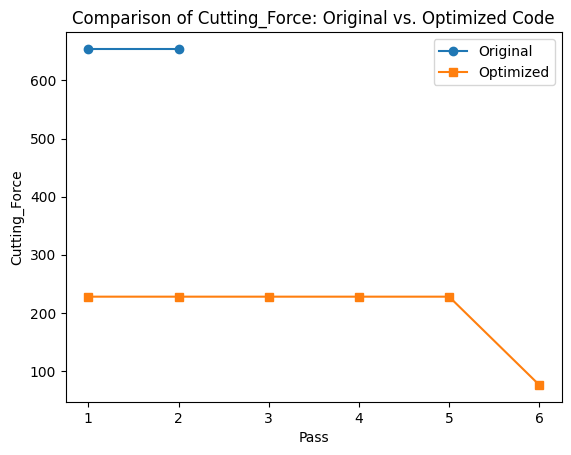

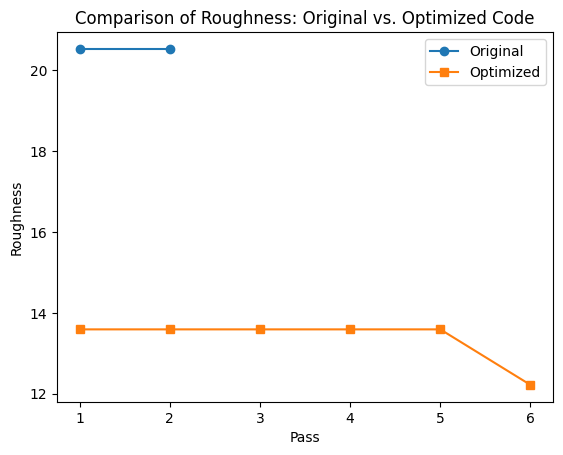

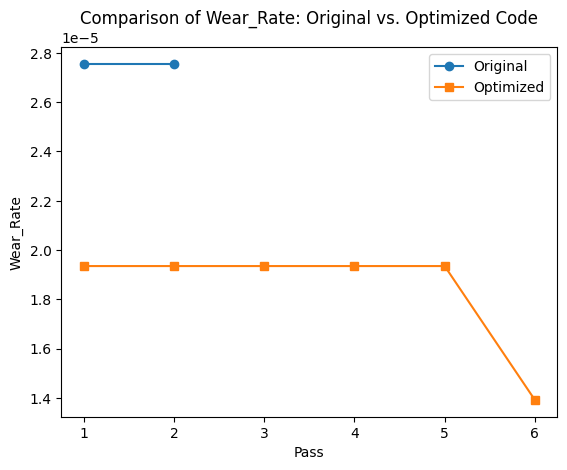

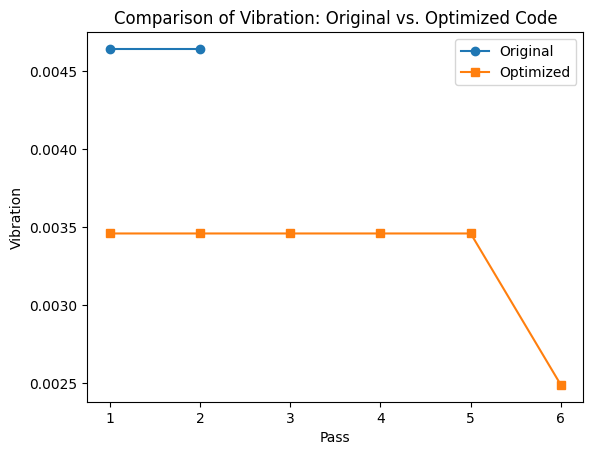

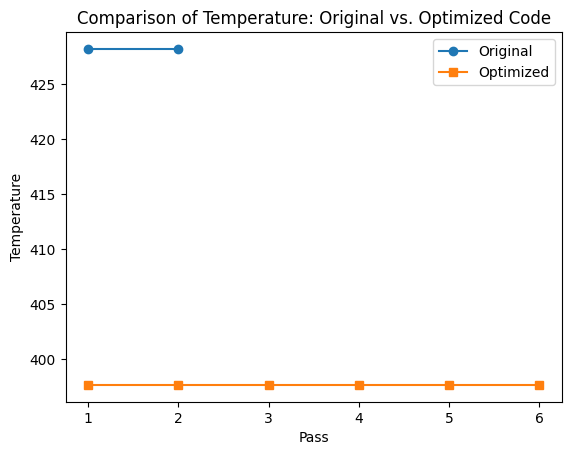

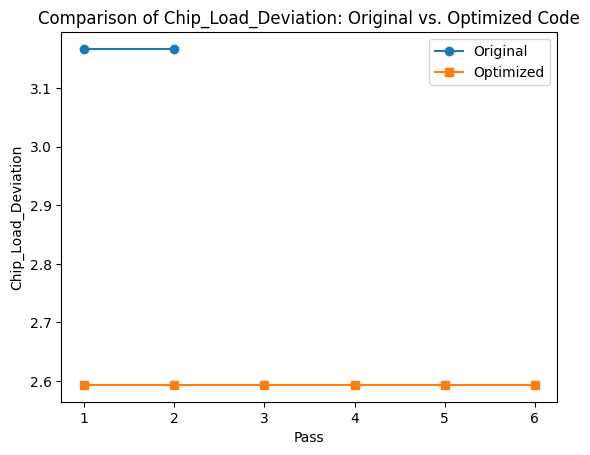

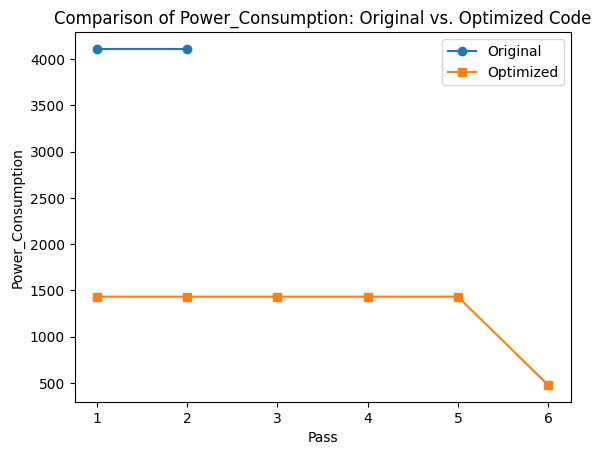

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- Wood Cutting Functions ----------------
def wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z):
    v_c = (np.pi * D * N) / 1000.0
    f_z = F / (N * z) if (N * z) else 0.0
    C_f = 15.0
    alpha_vc = 0.2
    alpha_fz = 0.5
    alpha_ap = 1.0
    alpha_w  = 0.4
    alpha_rk = 0.03
    alpha_rf = 0.02
    alpha_hx = -0.005
    chi_ct = np.sqrt(1.0 - (w / D)**2) if w < D else 1.0
    return (C_f *
            ((v_c / 120.0)**alpha_vc) *
            ((f_z / 0.08)**alpha_fz) *
            (ap**alpha_ap) *
            (w**alpha_w) *
            np.exp(alpha_rk * (rake - 8.0)) *
            np.exp(alpha_rf * (relief - 8.0)) *
            np.exp(alpha_hx * (helix - 35.0)) *
            chi_ct)

def wood_surface_roughness(N, F, ap, w, rake, relief, helix, D, z, corner_radius=1.0):
    v_c = (np.pi * D * N) / 1000.0
    f_z = F / (N * z) if (N * z) else 0.0
    R_geo = (f_z**2) / (8 * corner_radius) if corner_radius > 0 else f_z**2
    k_dyn = 0.3
    phi_ap = 0.3
    phi_w  = 0.2
    phi_rk = -0.01
    Delta_dyn = k_dyn * (ap**phi_ap) * (w**phi_w) * np.exp(phi_rk * (rake - 8.0))
    speed_factor = (120.0 / v_c)**0.15
    return (R_geo * (1.0 + Delta_dyn) * speed_factor) * 1e3

def wood_tool_wear_rate(N, F, ap, w, rake, relief, helix, D, z):
    v_c = (np.pi * D * N) / 1000.0
    f_z = F / (N * z) if (N * z) else 0.0
    C_w = 2.5e-6
    x_vc = 0.6
    x_fz = 0.4
    x_ap = 0.3
    x_w  = 0.2
    x_rk = 0.02
    x_rf = 0.01
    x_hx = 0.005
    return (C_w *
            ((v_c / 120.0)**x_vc) *
            ((f_z / 0.08)**x_fz) *
            (ap**x_ap) *
            (w**x_w) *
            np.exp(x_rk * (rake - 8.0)) *
            np.exp(x_rf * (relief - 8.0)) *
            np.exp(x_hx * (helix - 35.0)))

def wood_vibration_amplitude(N, F, ap, w, rake, relief, helix, D, z):
    omega_t = 2 * np.pi * (z * N / 60.0)
    omega_0 = 400.0
    C_v = 0.0008
    d1 = 0.2
    d2 = 0.3
    d3 = 0.4
    d_rk = 0.015
    d_rf = -0.01
    d_hx = 0.005
    return (C_v *
            ((omega_t / omega_0)**d1) *
            (ap**d2) *
            (w**d3) *
            np.exp(d_rk * (rake - 8.0)) *
            np.exp(d_rf * (relief - 8.0)) *
            np.exp(d_hx * (helix - 35.0)))

def wood_cutting_temperature(N, F, ap, w, rake, relief, helix, D, z):
    Fc = wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z)
    v_c = (np.pi * D * N) / 1000.0
    v_c_s = v_c / 60.0
    effective_area = w * ap if (w * ap) > 0 else 1.0
    C_t = 5.0
    return C_t * (Fc * v_c_s) / effective_area

def wood_chip_load_deviation(N, F, ap, w, rake, relief, helix, D, z):
    f_z = F / (N * z) if (N * z) else 0.0
    f_z_ideal = 0.08
    return abs(f_z - f_z_ideal) / f_z_ideal if f_z_ideal > 0 else 0.0

def wood_power_consumption(N, F, ap, w, rake, relief, helix, D, z):
    Fc = wood_cutting_force(N, F, ap, w, rake, relief, helix, D, z)
    v_c = (np.pi * D * N) / 1000.0
    v_c_s = v_c / 60.0
    return Fc * v_c_s

# Helper function
def compute_outputs(N, feed, ap, w=6.0, rake=14.0, relief=12.0, helix=35.0, D=10.0, z=2):
    """Compute the 7 output metrics in a dict."""
    return {
        "Cutting_Force": wood_cutting_force(N, feed, ap, w, rake, relief, helix, D, z),
        "Roughness": wood_surface_roughness(N, feed, ap, w, rake, relief, helix, D, z),
        "Wear_Rate": wood_tool_wear_rate(N, feed, ap, w, rake, relief, helix, D, z),
        "Vibration": wood_vibration_amplitude(N, feed, ap, w, rake, relief, helix, D, z),
        "Temperature": wood_cutting_temperature(N, feed, ap, w, rake, relief, helix, D, z),
        "Chip_Load_Deviation": wood_chip_load_deviation(N, feed, ap, w, rake, relief, helix, D, z),
        "Power_Consumption": wood_power_consumption(N, feed, ap, w, rake, relief, helix, D, z),
    }

# =======================
# 1) ORIGINAL CODE
#    2 passes: each pass is 8 mm depth
#    arcs feed=8000
original_passes = []
for i in range(1, 3):
    # pass depth = 8 mm
    pass_depth = 8.0
    results = compute_outputs(
        N=12000, feed=8000, ap=pass_depth,
        w=6.0, rake=14.0, relief=12.0, helix=35.0, D=10.0, z=2
    )
    results["Pass"] = i
    original_passes.append(results)

df_original = pd.DataFrame(original_passes)

# =======================
# 2) OPTIMIZED CODE
#    6 passes: five at 3 mm, one at 1 mm
#    arcs feed=6899.18
optimized_passes = []
for i in range(1, 6):
    pass_depth = 3.0
    res_opt = compute_outputs(
        N=12000, feed=6899.18, ap=pass_depth,
        w=6.0, rake=14.0, relief=12.0, helix=35.0, D=10.0, z=2
    )
    res_opt["Pass"] = i
    optimized_passes.append(res_opt)

# pass #6: 1 mm
res_opt6 = compute_outputs(
    N=12000, feed=6899.18, ap=1.0,
    w=6.0, rake=14.0, relief=12.0, helix=35.0, D=10.0, z=2
)
res_opt6["Pass"] = 6
optimized_passes.append(res_opt6)

df_optimized = pd.DataFrame(optimized_passes)

# Print the data
print("=== ORIGINAL CODE (2 passes) ===")
print(df_original)
print("\n=== OPTIMIZED CODE (6 passes) ===")
print(df_optimized)

# OPTIONAL: Averages
print("\nAverage for Original (over 2 passes):")
print(df_original.mean(numeric_only=True))

print("\nAverage for Optimized (over 6 passes):")
print(df_optimized.mean(numeric_only=True))

# =======================
# 3) PLOTTING
# We'll plot each metric on its own figure,
# comparing original vs. optimized pass-by-pass.

import matplotlib.pyplot as plt

metrics = [
    "Cutting_Force", "Roughness", "Wear_Rate",
    "Vibration", "Temperature", "Chip_Load_Deviation",
    "Power_Consumption"
]

for metric in metrics:
    plt.figure()  # one figure per metric (no subplots)
    # Plot Original
    plt.plot(df_original["Pass"], df_original[metric], marker='o', label='Original')
    # Plot Optimized
    plt.plot(df_optimized["Pass"], df_optimized[metric], marker='s', label='Optimized')

    plt.xlabel("Pass")
    plt.ylabel(metric)
    plt.title(f"Comparison of {metric}: Original vs. Optimized Code")
    plt.legend()
    plt.show()
